# **Notebook 3: Distributed Model Training & Hyperparameter Tuning**
**Input**: `data/features_parquet/{train,val,test}/` | **Algorithms**: Logistic Regression, Random Forest, GBT (CrossValidator), Linear SVC | **Baseline**: scikit-learn LR

## **1. SparkSession**

In [1]:
import os, time, json, warnings, pickle
warnings.filterwarnings('ignore')

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark import StorageLevel

spark = (
    SparkSession.builder
    .appName("HDFS_Anomaly_ModelTraining")
    .config("spark.driver.memory",          "6g")
    .config("spark.executor.memory",        "6g")
    .config("spark.executor.cores",         "2")
    .config("spark.sql.shuffle.partitions", "200")
    .config("spark.default.parallelism",    "8")
    .config("spark.sql.adaptive.enabled",   "true")
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")
    .master("local[*]")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")
spark.sparkContext.setCheckpointDir(
    os.path.join("/home/sayan/Lakhveer", "project", "data", "checkpoints")
)

BASE_DIR   = "/home/sayan/Lakhveer"
FEAT_DIR   = os.path.join(BASE_DIR, "project", "data", "features_parquet")
MODELS_DIR = os.path.join(BASE_DIR, "project", "data", "models")
os.makedirs(MODELS_DIR, exist_ok=True)

print(f"Spark version : {spark.version}")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/01 08:58:25 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version : 3.5.0


## **2. Load Feature Splits**

In [2]:
train_df = spark.read.parquet(os.path.join(FEAT_DIR, "train"))
val_df   = spark.read.parquet(os.path.join(FEAT_DIR, "val"))
test_df  = spark.read.parquet(os.path.join(FEAT_DIR, "test"))

train_df = train_df.persist(StorageLevel.MEMORY_AND_DISK)
val_df   = val_df.persist(StorageLevel.MEMORY_AND_DISK)
test_df  = test_df.persist(StorageLevel.MEMORY_AND_DISK)

n_train = train_df.count()
n_val   = val_df.count()
n_test  = test_df.count()
print(f"Train: {n_train:,}  |  Val: {n_val:,}  |  Test: {n_test:,}")
train_df.printSchema()

Train: 2,071,469  |  Val: 689,702  |  Test: 689,195
root
 |-- std_features: vector (nullable = true)
 |-- mm_features: vector (nullable = true)
 |-- raw_features: vector (nullable = true)
 |-- Label: integer (nullable = true)
 |-- class_weight: double (nullable = true)



## **3. Scikit-learn Baseline (Single-Node)**

In [3]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

sk_train = train_df.sample(fraction=0.02, seed=42).toPandas()
sk_test  = test_df.sample(fraction=0.02, seed=42).toPandas()

def extract_array(pdf, col="std_features"):
    return np.vstack(pdf[col].apply(lambda v: v.toArray()))

X_sk_train = extract_array(sk_train)
y_sk_train = sk_train['Label'].values
X_sk_test  = extract_array(sk_test)
y_sk_test  = sk_test['Label'].values

print(f"SK train shape: {X_sk_train.shape}  SK test shape: {X_sk_test.shape}")

t0 = time.time()
sk_lr = LogisticRegression(max_iter=500, class_weight='balanced', random_state=42)
sk_lr.fit(X_sk_train, y_sk_train)
sk_train_time = time.time() - t0

sk_pred  = sk_lr.predict(X_sk_test)
sk_proba = sk_lr.predict_proba(X_sk_test)[:, 1] if hasattr(sk_lr, 'predict_proba') else sk_pred

SK_RESULTS = {
    "model"       : "SK-LearnLR (single-node, 2% sample)",
    "accuracy"    : round(accuracy_score(y_sk_test, sk_pred), 4),
    "f1_weighted" : round(f1_score(y_sk_test, sk_pred, average='weighted'), 4),
    "roc_auc"     : round(roc_auc_score(y_sk_test, sk_proba), 4),
    "train_time_s": round(sk_train_time, 2),
    "sample_rows" : len(X_sk_train),
}
print("\nScikit-learn Baseline Results:")
for k, v in SK_RESULTS.items():
    print(f"  {k:20s}: {v}")
print("\nClassification Report:")
print(classification_report(y_sk_test, sk_pred, target_names=['Normal','Anomaly']))

with open(os.path.join(MODELS_DIR, 'sklearn_lr_baseline.pkl'), 'wb') as fh:
    pickle.dump({'model': sk_lr, 'results': SK_RESULTS}, fh)
print("Sklearn baseline saved.")

SK train shape: (41332, 56)  SK test shape: (13941, 56)

Scikit-learn Baseline Results:
  model               : SK-LearnLR (single-node, 2% sample)
  accuracy            : 0.9803
  f1_weighted         : 0.9826
  roc_auc             : 0.995
  train_time_s        : 1.66
  sample_rows         : 41332

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99     13545
     Anomaly       0.59      0.97      0.74       396

    accuracy                           0.98     13941
   macro avg       0.80      0.98      0.86     13941
weighted avg       0.99      0.98      0.98     13941

Sklearn baseline saved.


## **4. MLlib Model 1 – Logistic Regression**

In [4]:
from pyspark.ml.classification import (
    LogisticRegression,
    RandomForestClassifier,
    GBTClassifier,
    LinearSVC,
)
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

FEATURE_COL = "std_features"
LABEL_COL   = "Label"
results     = {}

lr = LogisticRegression(
    featuresCol=FEATURE_COL, labelCol=LABEL_COL,
    maxIter=100, regParam=0.01, elasticNetParam=0.0,
    standardization=False,
    weightCol="class_weight",
    probabilityCol="probability", rawPredictionCol="rawPrediction",
)
t0            = time.time()
lr_model      = lr.fit(train_df)
lr_train_time = time.time() - t0
print(f"LR trained in {lr_train_time:.1f}s")
print(f"LR iterations: {lr_model.summary.totalIterations}")

26/03/01 08:59:12 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/03/01 08:59:12 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS


LR trained in 18.9s
LR iterations: 61


In [5]:
bin_eval   = BinaryClassificationEvaluator(labelCol=LABEL_COL, rawPredictionCol="rawPrediction")
mc_eval_f1 = MulticlassClassificationEvaluator(labelCol=LABEL_COL, predictionCol="prediction", metricName="f1")
mc_eval_acc = MulticlassClassificationEvaluator(labelCol=LABEL_COL, predictionCol="prediction", metricName="accuracy")

lr_val_pred = lr_model.transform(val_df)
lr_auc      = bin_eval.evaluate(lr_val_pred)
lr_f1       = mc_eval_f1.evaluate(lr_val_pred)
lr_acc      = mc_eval_acc.evaluate(lr_val_pred)

results['LogisticRegression'] = {
    'train_time_s': round(lr_train_time, 2),
    'val_auc_roc' : round(lr_auc, 4),
    'val_f1'      : round(lr_f1, 4),
    'val_acc'     : round(lr_acc, 4),
}
print(f"LR   Val AUC={lr_auc:.4f}  F1={lr_f1:.4f}  Acc={lr_acc:.4f}")

lr_model.write().overwrite().save(os.path.join(MODELS_DIR, "lr_model"))
print("LR model saved.")

LR   Val AUC=0.9927  F1=0.9649  Acc=0.9562
LR model saved.


## **5. MLlib Model 2 – Random Forest Classifier**

In [6]:
RF_FEATURE_COL = "raw_features"

rf = RandomForestClassifier(
    featuresCol=RF_FEATURE_COL, labelCol=LABEL_COL,
    numTrees=100, maxDepth=10, maxBins=32,
    subsamplingRate=0.8, featureSubsetStrategy="sqrt",
    seed=42,
)
t0            = time.time()
rf_model      = rf.fit(train_df)
rf_train_time = time.time() - t0

rf_val_pred = rf_model.transform(val_df)
rf_auc  = bin_eval.setParams(rawPredictionCol='rawPrediction').evaluate(rf_val_pred)
rf_f1   = mc_eval_f1.evaluate(rf_val_pred)
rf_acc  = mc_eval_acc.evaluate(rf_val_pred)

results['RandomForest'] = {
    'train_time_s': round(rf_train_time, 2),
    'val_auc_roc' : round(rf_auc, 4),
    'val_f1'      : round(rf_f1, 4),
    'val_acc'     : round(rf_acc, 4),
}
print(f"RF   Val AUC={rf_auc:.4f}  F1={rf_f1:.4f}  Acc={rf_acc:.4f}  ({rf_train_time:.1f}s)")

rf_model.write().overwrite().save(os.path.join(MODELS_DIR, "rf_model"))
print("RF model saved.")

26/03/01 09:02:52 WARN DAGScheduler: Broadcasting large task binary with size 1392.5 KiB
26/03/01 09:03:16 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
26/03/01 09:03:41 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
26/03/01 09:04:07 WARN DAGScheduler: Broadcasting large task binary with size 2.0 MiB
26/03/01 09:04:16 WARN DAGScheduler: Broadcasting large task binary with size 2.0 MiB
26/03/01 09:04:24 WARN DAGScheduler: Broadcasting large task binary with size 2.0 MiB


RF   Val AUC=0.9997  F1=0.9969  Acc=0.9969  (209.7s)
RF model saved.


## **6. MLlib Model 3 – Gradient Boosted Trees with CrossValidator**

In [7]:
gbt = GBTClassifier(
    featuresCol=RF_FEATURE_COL, labelCol=LABEL_COL,
    maxIter=50, maxDepth=5, stepSize=0.1,
    subsamplingRate=0.8, seed=42,
    checkpointInterval=10,
)

param_grid = (
    ParamGridBuilder()
    .addGrid(gbt.maxDepth, [4, 6])
    .addGrid(gbt.stepSize, [0.05, 0.1, 0.2])
    .build()
)
print(f"GBT grid size: {len(param_grid)} configurations")

cv = CrossValidator(
    estimator=gbt,
    estimatorParamMaps=param_grid,
    evaluator=BinaryClassificationEvaluator(labelCol=LABEL_COL),
    numFolds=3,
    parallelism=2,
    seed=42,
    collectSubModels=False,
)

t0             = time.time()
cv_df          = train_df.union(val_df)
cv_model       = cv.fit(cv_df)
gbt_train_time = time.time() - t0

best_gbt = cv_model.bestModel
print(f"\nGBT CV completed in {gbt_train_time:.1f}s")
print(f"Best maxDepth : {best_gbt.getMaxDepth()}")
print(f"Best stepSize : {best_gbt.getStepSize()}")
print(f"CV AUC scores : {[round(x,4) for x in cv_model.avgMetrics]}")

GBT grid size: 6 configurations



GBT CV completed in 2658.9s
Best maxDepth : 6
Best stepSize : 0.2
CV AUC scores : [np.float64(0.9977), np.float64(0.9984), np.float64(0.9991), np.float64(0.9994), np.float64(0.9996), np.float64(0.9997)]


In [8]:
gbt_val_pred = best_gbt.transform(val_df)
gbt_auc      = bin_eval.evaluate(gbt_val_pred)
gbt_f1       = mc_eval_f1.evaluate(gbt_val_pred)
gbt_acc      = mc_eval_acc.evaluate(gbt_val_pred)

results['GBT'] = {
    'train_time_s' : round(gbt_train_time, 2),
    'val_auc_roc'  : round(gbt_auc, 4),
    'val_f1'       : round(gbt_f1, 4),
    'val_acc'      : round(gbt_acc, 4),
    'best_maxDepth': best_gbt.getMaxDepth(),
    'best_stepSize': best_gbt.getStepSize(),
}
print(f"GBT  Val AUC={gbt_auc:.4f}  F1={gbt_f1:.4f}  Acc={gbt_acc:.4f}")

best_gbt.write().overwrite().save(os.path.join(MODELS_DIR, "gbt_model"))
print("GBT model saved.")

GBT  Val AUC=0.9997  F1=0.9983  Acc=0.9983
GBT model saved.


## **7. MLlib Model 4 – Linear SVC**

In [9]:
svc = LinearSVC(
    featuresCol=FEATURE_COL, labelCol=LABEL_COL,
    maxIter=100, regParam=0.01,
    weightCol="class_weight",
)
t0             = time.time()
svc_model      = svc.fit(train_df)
svc_train_time = time.time() - t0

svc_val_pred = svc_model.transform(val_df)
svc_auc  = bin_eval.setParams(rawPredictionCol='rawPrediction').evaluate(svc_val_pred)
svc_f1   = mc_eval_f1.evaluate(svc_val_pred)
svc_acc  = mc_eval_acc.evaluate(svc_val_pred)

results['LinearSVC'] = {
    'train_time_s': round(svc_train_time, 2),
    'val_auc_roc' : round(svc_auc, 4),
    'val_f1'      : round(svc_f1, 4),
    'val_acc'     : round(svc_acc, 4),
}
print(f"SVC  Val AUC={svc_auc:.4f}  F1={svc_f1:.4f}  Acc={svc_acc:.4f}  ({svc_train_time:.1f}s)")

svc_model.write().overwrite().save(os.path.join(MODELS_DIR, "svc_model"))
print("SVC model saved.")

SVC  Val AUC=0.9917  F1=0.9594  Acc=0.9479  (24.1s)
SVC model saved.


## **8. Model Comparison Table**

Validation Comparison Table:
             Model  val_auc_roc  val_f1  val_acc  train_time_s
  SK-LR (baseline)       0.9950  0.9826   0.9803          1.66
LogisticRegression       0.9927  0.9649   0.9562         18.87
      RandomForest       0.9997  0.9969   0.9969        209.72
               GBT       0.9997  0.9983   0.9983       2658.86
         LinearSVC       0.9917  0.9594   0.9479         24.10


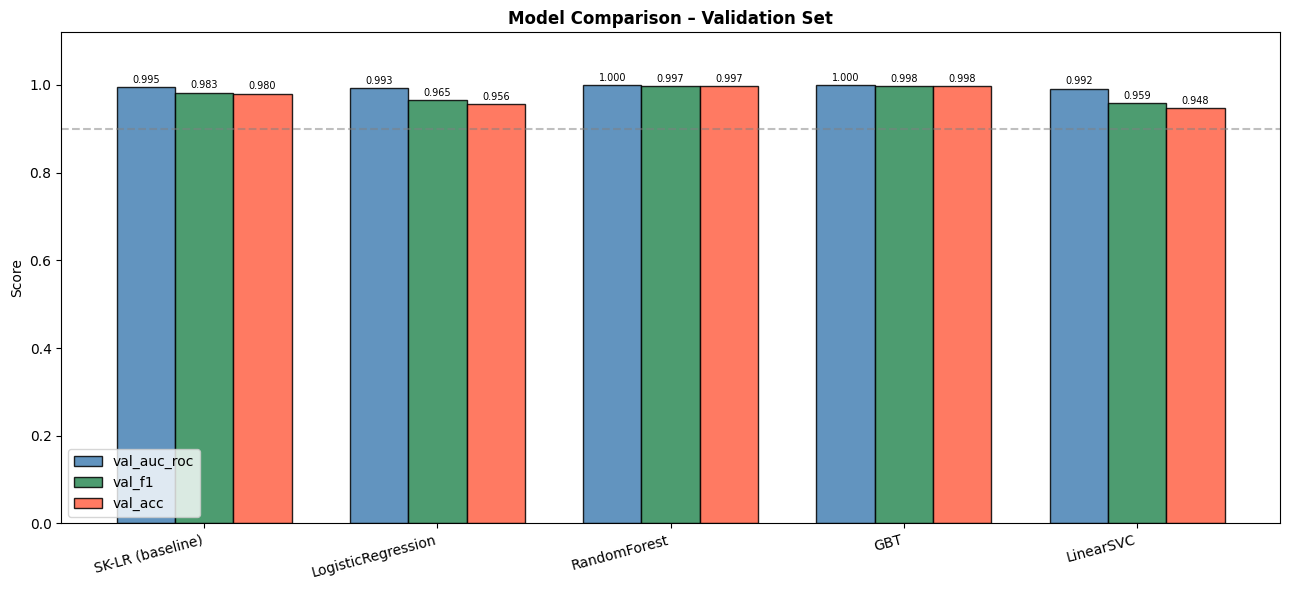

In [10]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

all_results = {
    'SK-LR (baseline)': {
        'train_time_s': SK_RESULTS['train_time_s'],
        'val_auc_roc' : SK_RESULTS['roc_auc'],
        'val_f1'      : SK_RESULTS['f1_weighted'],
        'val_acc'     : SK_RESULTS['accuracy'],
    },
    **results
}

results_df = pd.DataFrame(all_results).T.reset_index()
results_df.columns = ['Model'] + list(results_df.columns[1:])
results_df = results_df[['Model','val_auc_roc','val_f1','val_acc','train_time_s']]
results_df[['val_auc_roc','val_f1','val_acc','train_time_s']] = (
    results_df[['val_auc_roc','val_f1','val_acc','train_time_s']].astype(float)
)
print("Validation Comparison Table:")
print(results_df.to_string(index=False))

results_df.to_csv(
    os.path.join(BASE_DIR, 'project/data/samples/model_comparison.csv'), index=False
)

metrics = ['val_auc_roc', 'val_f1', 'val_acc']
x       = np.arange(len(results_df))
width   = 0.25
colors  = ['steelblue', 'seagreen', 'tomato']

fig, ax = plt.subplots(figsize=(13, 6))
for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax.bar(x + i*width, results_df[metric], width, label=metric, color=color, alpha=0.85, edgecolor='black')

ax.set_xticks(x + width)
ax.set_xticklabels(results_df['Model'], rotation=15, ha='right')
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('Model Comparison – Validation Set', fontweight='bold')
ax.legend()
ax.axhline(0.9, color='gray', linestyle='--', alpha=0.5)
for rect in ax.patches:
    h = rect.get_height()
    if h > 0.01:
        ax.annotate(f"{h:.3f}", xy=(rect.get_x() + rect.get_width()/2, h),
                    xytext=(0,3), textcoords="offset points", ha='center', fontsize=7)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR,'project/data/samples/model_comparison_bar.png'), bbox_inches='tight')
plt.show()

## **9. Feature Importance (Random Forest & GBT)**

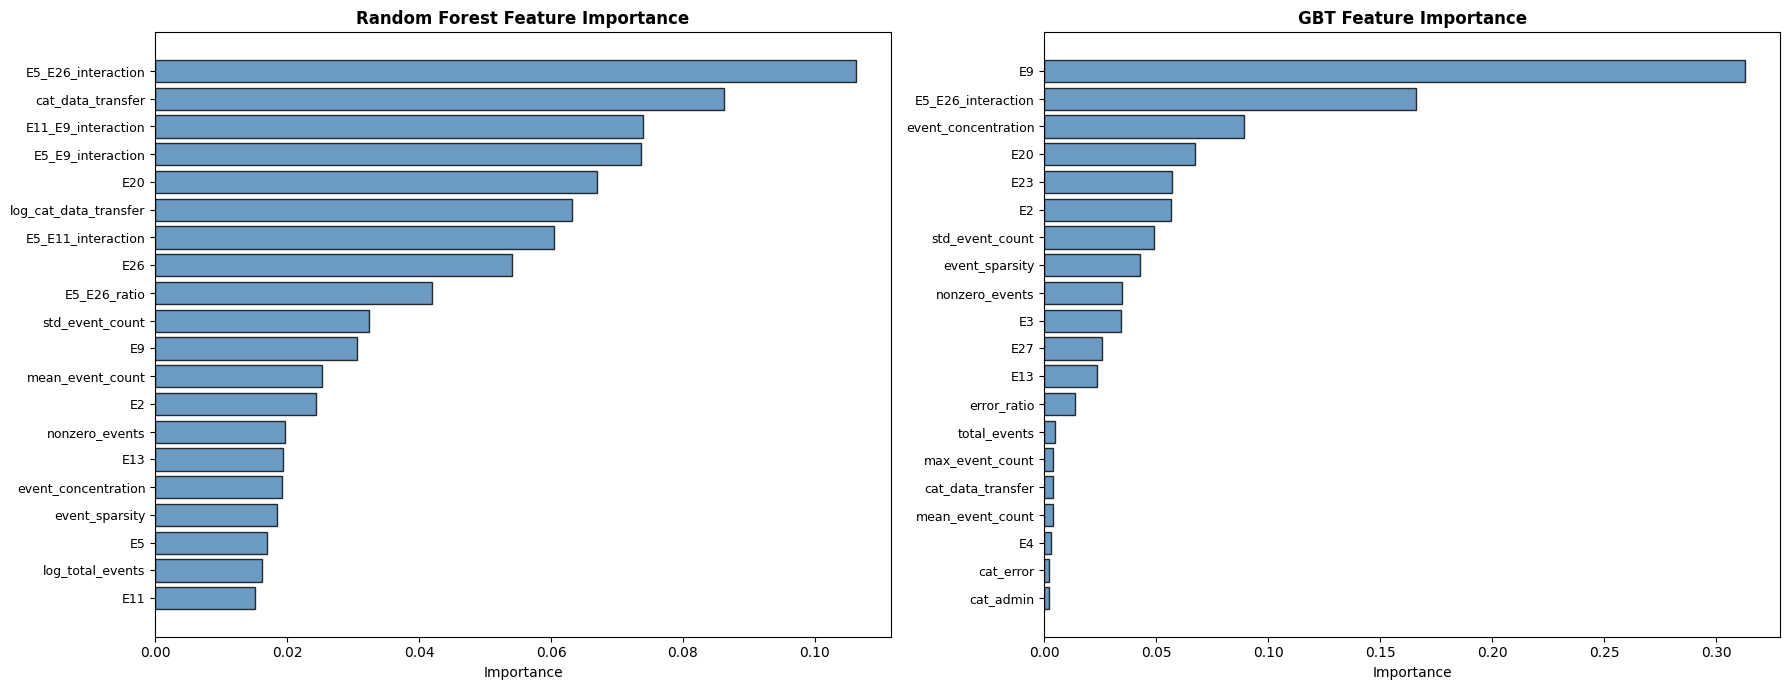

In [11]:
with open(os.path.join(BASE_DIR, "project", "data", "schemas", "feature_metadata.json")) as fp:
    feat_meta  = json.load(fp)
feature_names = feat_meta['feature_cols']

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, model, title in [
    (axes[0], rf_model,  "Random Forest Feature Importance"),
    (axes[1], best_gbt,  "GBT Feature Importance"),
]:
    importances = model.featureImportances.toArray()
    n     = min(len(importances), len(feature_names))
    top_k = 20
    idx   = np.argsort(importances[:n])[::-1][:top_k]
    names  = [feature_names[i] if i < len(feature_names) else f"f{i}" for i in idx]
    values = importances[idx]
    ax.barh(range(top_k), values[::-1], color='steelblue', edgecolor='black', alpha=0.8)
    ax.set_yticks(range(top_k))
    ax.set_yticklabels(names[::-1], fontsize=9)
    ax.set_xlabel('Importance')
    ax.set_title(title, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR,'project/data/samples/feature_importance.png'), bbox_inches='tight')
plt.show()

## **10. Scalability Analysis – Strong & Weak Scaling**

In [12]:
print("Strong Scaling – fixed 200K rows, varying partitions:")
strong_results = []
for n_parts in [2, 4, 8, 16]:
    sample_df = train_df.repartition(n_parts).limit(200_000)
    sample_df.cache(); sample_df.count()
    lr_s = LogisticRegression(featuresCol=FEATURE_COL, labelCol=LABEL_COL, maxIter=20)
    t0   = time.time()
    lr_s.fit(sample_df)
    elapsed = time.time() - t0
    strong_results.append({'partitions': n_parts, 'train_time_s': round(elapsed, 2)})
    sample_df.unpersist()
    print(f"  partitions={n_parts:2d}  time={elapsed:.2f}s")

print("\nWeak Scaling – data grows with partitions:")
weak_results = []
BASE_ROWS = 50_000
for n_parts in [2, 4, 8, 16]:
    row_count = BASE_ROWS * n_parts
    sample_df = train_df.repartition(n_parts).limit(row_count)
    sample_df.cache(); sample_df.count()
    lr_w = LogisticRegression(featuresCol=FEATURE_COL, labelCol=LABEL_COL, maxIter=20)
    t0   = time.time()
    lr_w.fit(sample_df)
    elapsed = time.time() - t0
    weak_results.append({'partitions': n_parts, 'rows': row_count, 'train_time_s': round(elapsed, 2)})
    sample_df.unpersist()
    print(f"  partitions={n_parts:2d}  rows={row_count:,}  time={elapsed:.2f}s")

Strong Scaling – fixed 200K rows, varying partitions:


26/03/01 09:50:04 WARN Instrumentation: [1607224f] All labels are the same value and fitIntercept=true, so the coefficients will be zeros. Training is not needed.


  partitions= 2  time=0.47s


26/03/01 09:50:11 WARN Instrumentation: [6c684bca] All labels are the same value and fitIntercept=true, so the coefficients will be zeros. Training is not needed.


  partitions= 4  time=0.49s


...

  partitions= 2  rows=100,000  time=0.23s


26/03/01 09:50:40 WARN Instrumentation: [4b4a667f] All labels are the same value and fitIntercept=true, so the coefficients will be zeros. Training is not needed.


  partitions= 4  rows=200,000  time=0.36s


  partitions= 8  rows=400,000  time=2.14s


  partitions=16  rows=800,000  time=4.04s


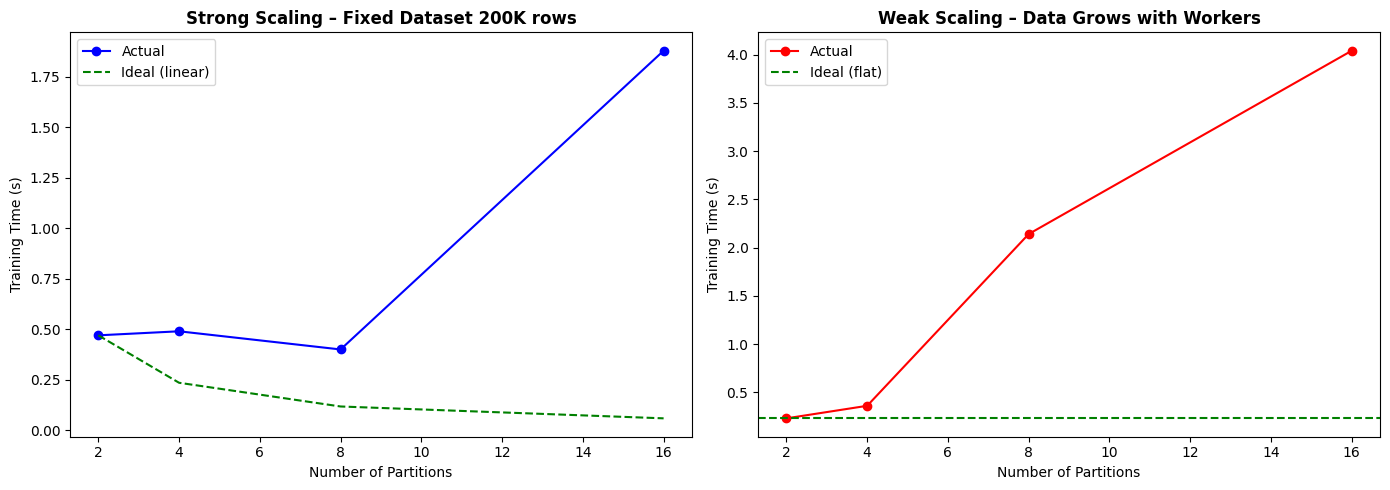

Scaling data saved.


In [13]:
strong_df = pd.DataFrame(strong_results)
weak_df   = pd.DataFrame(weak_results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ideal_strong = strong_df['train_time_s'].iloc[0] / (strong_df['partitions'] / strong_df['partitions'].iloc[0])
axes[0].plot(strong_df['partitions'], strong_df['train_time_s'], 'b-o', label='Actual')
axes[0].plot(strong_df['partitions'], ideal_strong, 'g--', label='Ideal (linear)')
axes[0].set_xlabel('Number of Partitions')
axes[0].set_ylabel('Training Time (s)')
axes[0].set_title('Strong Scaling – Fixed Dataset 200K rows', fontweight='bold')
axes[0].legend()

axes[1].plot(weak_df['partitions'], weak_df['train_time_s'], 'r-o', label='Actual')
axes[1].axhline(weak_df['train_time_s'].iloc[0], color='g', linestyle='--', label='Ideal (flat)')
axes[1].set_xlabel('Number of Partitions')
axes[1].set_ylabel('Training Time (s)')
axes[1].set_title('Weak Scaling – Data Grows with Workers', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR,'project/data/samples/scaling_analysis.png'), bbox_inches='tight')
plt.show()

strong_df.to_csv(os.path.join(BASE_DIR,'project/data/samples/strong_scaling.csv'), index=False)
weak_df.to_csv(os.path.join(BASE_DIR,'project/data/samples/weak_scaling.csv'), index=False)
print("Scaling data saved.")

## **11. Save All Results**

In [14]:
with open(os.path.join(BASE_DIR, 'project/data/samples/all_results.json'), 'w') as fp:
    json.dump({
        'sklearn_baseline': SK_RESULTS,
        'mllib_models'    : results,
        'strong_scaling'  : strong_results,
        'weak_scaling'    : weak_results,
    }, fp, indent=2)
print("All results saved.")

for df_ in [train_df, val_df, test_df]:
    df_.unpersist()

print("\n✓  Notebook 3 complete.")

All results saved.

✓  Notebook 3 complete.
